# Heavy Machinery Price Prediction

## 1. Importing all the libraries

In [1]:
import os
import re
import warnings
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from scipy.stats import randint, uniform
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

# Loading Data

In [2]:
warnings.filterwarnings("ignore")
NB_START = time.time() #we are using time for safeguarding the notebook against lengthy training of model like catboost
DATA_DIR = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge" 
train_raw = pd.read_csv(os.path.join(DATA_DIR, "train.csv"), low_memory=False)
test_raw  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"),  low_memory=False)
print("train:", train_raw.shape, "| test:", test_raw.shape)
TARGET = "TargetValue"

train: (138701, 50) | test: (15000, 49)


## 2. Class wise visualisation and EDA

| Class | Domain Focus | Columns |
|---|---|---|
| Class 1 | Transaction & Business Context | `TransactionID`, `TargetValue`, `TransactionDate`, `RegionCode`, `DataOriginCode`, `VendorPartnerID` |
| Class 2 | Asset Identity & Work History | `AssetID`, `ProductConfigID`, `ManufactureYear`, `OperationalHoursMeter`, `UtilizationTier` |
| Class 3 | Equipment Classification & Taxonomy | `Spec_*`, `Inventory*`, `AssetScaleFactor`, `FunctionalClassification` |
| Class 4 | Engine, Power & Core Systems | `DrivetrainType`, `col1`, `col5`, `col9`, `col10`, `col14`, `col19`, `col24`, `col29` |
| Class 5 | Arms, Attachments & Working Tools | `Forks`, `col4`, `col6`, `col7`, `col12`, `col13`, `col16`, `col22`, `col23`, `col27` |
| Class 6 | Cabin, Steering & Ground Interface | `CabinType`, `col3`, `col8`, `col11`, `col15`, `col18`, `col20`, `col21`, `col25`, `col28`, `col30` |

### Class 1

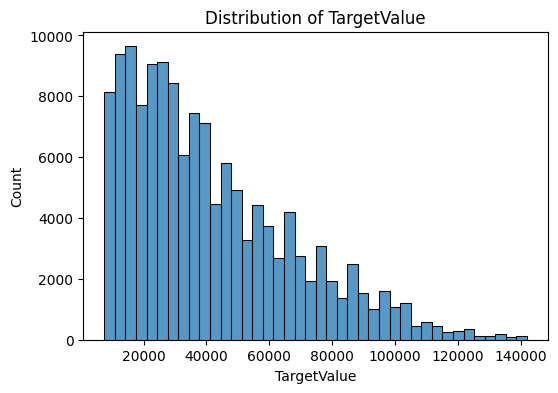

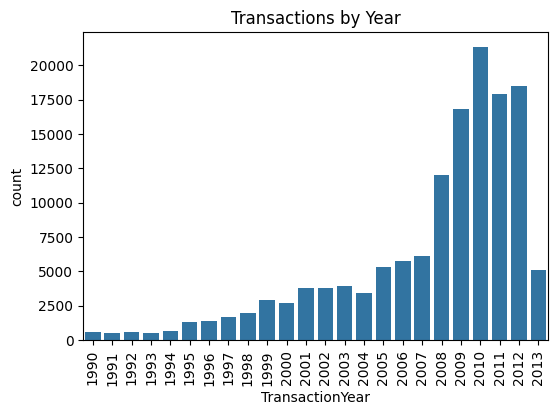

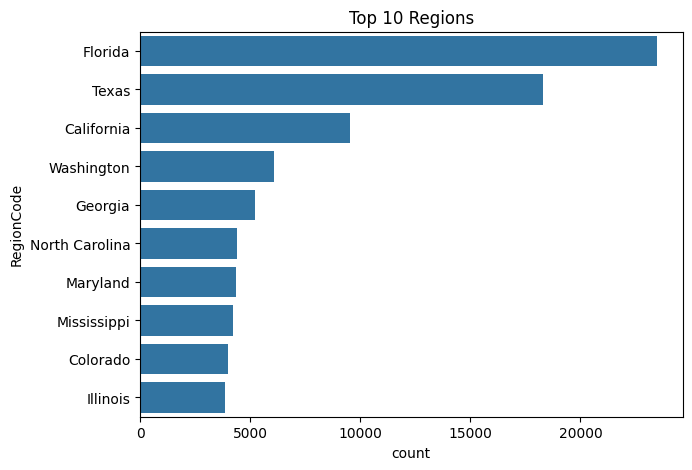

In [3]:
class1_cols = [
    "TransactionID",
    "TargetValue",
    "TransactionDate",
    "RegionCode",
    "DataOriginCode",
    "VendorPartnerID"
]

class1_df = train_raw[class1_cols].copy()

class1_df["TransactionDate"] = pd.to_datetime(
    class1_df["TransactionDate"], errors="coerce"
)

class1_df["TransactionYear"] = class1_df["TransactionDate"].dt.year

plt.figure(figsize=(6,4))
sns.histplot(class1_df["TargetValue"], bins=40)
plt.title("Distribution of TargetValue")
plt.xlabel("TargetValue")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="TransactionYear", data=class1_df)
plt.title("Transactions by Year")
plt.xticks(rotation=90)
plt.show()

top_regions = class1_df["RegionCode"].value_counts().head(10).index
plt.figure(figsize=(7,5))
sns.countplot(y="RegionCode", data=class1_df, order=top_regions)
plt.title("Top 10 Regions")
plt.show()

### Key Insights from Class 1 Visualizations

* **Right-Skewed Target Distribution:** The resale price (`TargetValue`) is heavily right-skewed, with most heavy machinery selling in the $15,000–$50,000 range. Very few assets sell above $100,000. Because of this long tail, applying a log transformation (`log1p`) before modeling is crucial to stabilize the variance and optimize for RMSLE.
* **Rapid Transaction Growth (with 2008 Spike):** Transaction volume grew steadily from 1990 until experiencing a massive surge starting around 2008–2010 (peaking at over 20,000 sales in 2010). Note that the drop-off in 2013 is likely an artifact of the dataset collection period ending mid-year rather than an actual market crash.
* **Geographic Dominance:** Sales are heavily concentrated in a few key states. **Florida** leads by a wide margin with nearly 24,000 transactions, followed by **Texas** (18,500) and **California** (9,500). These top states likely correspond to major construction, mining, or agricultural hubs where machinery turnover is highest.

In [4]:
print("Class 1 shape:", class1_df.shape)
print("\nMissing values:")
print(class1_df.isna().sum())
print("\nTargetValue summary:")
print(class1_df["TargetValue"].describe())
print("\nTransaction date range:")
print(class1_df["TransactionDate"].min(), "to", class1_df["TransactionDate"].max())
print("\nUnique values:")
print(class1_df[["TransactionID", "RegionCode", "DataOriginCode", "VendorPartnerID"]].nunique())
print("\nTop DataOriginCode values:")
print(class1_df["DataOriginCode"].value_counts().head())
print("\nTop VendorPartnerID values:")
print(class1_df["VendorPartnerID"].value_counts().head())


Class 1 shape: (138701, 7)

Missing values:
TransactionID      0
TargetValue        0
TransactionDate    0
RegionCode         0
DataOriginCode     0
VendorPartnerID    0
TransactionYear    0
dtype: int64

TargetValue summary:
count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

Transaction date range:
1990-01-31 00:00:00 to 2013-04-28 00:00:00

Unique values:
TransactionID      138701
RegionCode             53
DataOriginCode          6
VendorPartnerID        31
dtype: int64

Top DataOriginCode values:
DataOriginCode
ADI149    59541
CEA153    36009
ACH138    16909
FFA166    13423
IHB189    12818
Name: count, dtype: int64

Top VendorPartnerID values:
VendorPartnerID
UJF               67828
GTX               18231
MPF               15187
UNKNOWN_VENDOR     6549
HCL                5753
Name: count, dtype: int64


### Class 2

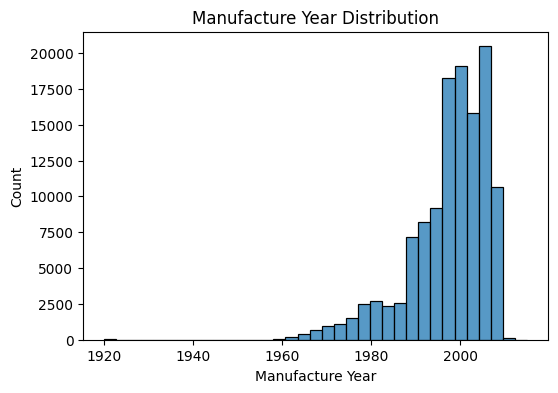

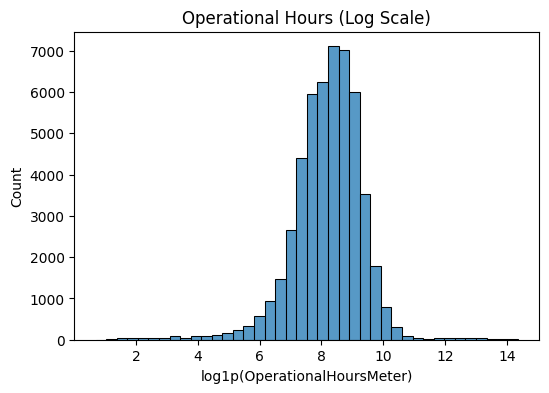

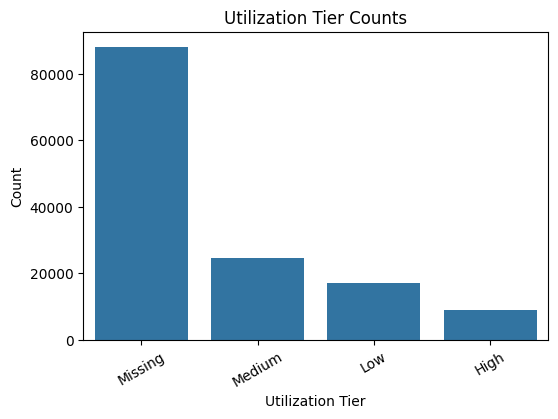

In [5]:
class2_cols = [
    "AssetID",
    "ProductConfigID",
    "ManufactureYear",
    "OperationalHoursMeter",
    "UtilizationTier"
]

class2_df = train_raw[class2_cols].copy()
valid_years = class2_df[
    (class2_df["ManufactureYear"] >= 1900) &
    (class2_df["ManufactureYear"] <= 2025)
]

plt.figure(figsize=(6,4))
sns.histplot(valid_years["ManufactureYear"], bins=35)
plt.title("Manufacture Year Distribution")
plt.xlabel("Manufacture Year")
plt.ylabel("Count")
plt.show()

positive_hours = class2_df[class2_df["OperationalHoursMeter"] > 0].copy()
positive_hours["HoursLog"] = np.log1p(positive_hours["OperationalHoursMeter"])

plt.figure(figsize=(6,4))
sns.histplot(positive_hours["HoursLog"], bins=40)
plt.title("Operational Hours (Log Scale)")
plt.xlabel("log1p(OperationalHoursMeter)")
plt.ylabel("Count")
plt.show()

util_order = class2_df["UtilizationTier"].fillna("Missing").value_counts().index

plt.figure(figsize=(6,4))
sns.countplot(x=class2_df["UtilizationTier"].fillna("Missing"),order=util_order)

plt.title("Utilization Tier Counts")
plt.xticks(rotation=30)
plt.xlabel("Utilization Tier")
plt.ylabel("Count")
plt.show()

### Key Insights from Class 2 Visualizations (Asset History)

* **Modern Fleet Concentration:** The manufacture year distribution shows that the vast majority of equipment in the dataset was built after 1990, peaking sharply between 2000 and 2008. There is a noticeable drop-off after 2008 (aligning with the broader economic downturn and dataset collection timeframe), as well as a tiny cluster of invalid outliers around 1920 that require filtering or capping during preprocessing.
* **Log-Normal Operational Hours:** Raw operational hours are heavily skewed, but applying a log transformation (`log1p`) reveals a normal, bell-shaped distribution centered around a log value of ~8.5 (which translates to roughly 4,900 operating hours). This confirms that log-transforming this feature will provide much cleaner signals for tree-based models and prevent extreme usage numbers from hampering predictions.
* **High Missingness in Utilization:** The `UtilizationTier` feature is dominated by missing values, with over 80,000 assets lacking a recorded tier. Among the recorded categories, "Medium" is the most common, followed by "Low" and "High". Because missingness is so prevalent, we must treat "Missing" as its own explicit category rather than imputing it, as the absence of a utilization rating likely carries significant business signal.

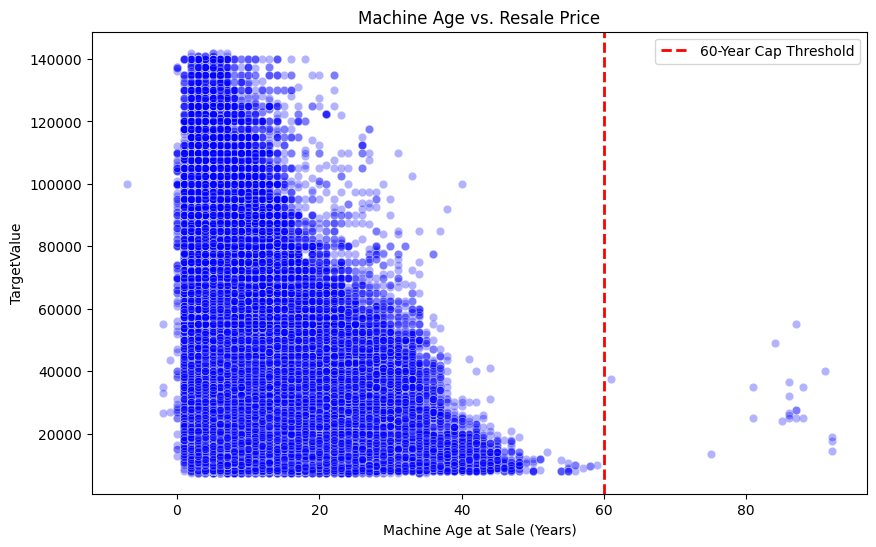

In [6]:
scatter_data = train_raw[["ManufactureYear", "TransactionDate", "TargetValue"]].copy()

scatter_data["TransactionDate"] = pd.to_datetime(scatter_data["TransactionDate"], errors="coerce")
scatter_data["txn_year"] = scatter_data["TransactionDate"].dt.year

valid_mask = (scatter_data["ManufactureYear"] >= 1900) & (scatter_data["ManufactureYear"] <= 2025)
scatter_data["ManufactureYear_clean"] = scatter_data["ManufactureYear"].where(valid_mask)

scatter_data["machine_age"] = scatter_data["txn_year"] - scatter_data["ManufactureYear_clean"]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_data, x="machine_age", y="TargetValue", alpha=0.3,  color="blue")
plt.axvline(x=60, color="red", linestyle="--", linewidth=2, label="60-Year Cap Threshold")
plt.title("Machine Age vs. Resale Price")
plt.xlabel("Machine Age at Sale (Years)")
plt.ylabel("TargetValue")
plt.legend()
plt.show()

### Why We Plotted This
We created this scatter plot to confirm how strongly a machine's age impacts its resale price, and to visually check for extreme outliers or data entry errors before training our models.

### Key Insights
* **Strong Depreciation Signal:** There is a clear negative correlation—as machine age increases, resale value steadily drops. Newer machines (0–15 years old) command the highest prices (up to $140,000), while older equipment converges toward a lower baseline value.
* **Justifying the 60-Year Cap:** Notice the sparse cluster of extreme outliers past 80–90 years (likely typing errors in the manufacture year or transaction date). The red dashed line visually justifies our decision to cap (`clip`) machine age at 60 years, ensuring these noisy outliers don't confuse our decision trees.

In [7]:
print("Class 2 shape:", class2_df.shape)
print("\nMissing values:")
print(class2_df.isna().sum())
print("\nNumeric summary:")
print(class2_df[["AssetID", "ProductConfigID", "ManufactureYear", "OperationalHoursMeter"]].describe())

invalid_years = ((class2_df["ManufactureYear"] < 1900) |
                 (class2_df["ManufactureYear"] > 2025)).sum()
zero_hours = (class2_df["OperationalHoursMeter"] == 0).sum()
print("\nInvalid manufacture years (count):", invalid_years)
print("Zero operational-hour readings (count):", zero_hours)

print("\nUtilizationTier counts:")
print(class2_df["UtilizationTier"].fillna("Missing").value_counts())


Class 2 shape: (138701, 5)

Missing values:
AssetID                      0
ProductConfigID              0
ManufactureYear              0
OperationalHoursMeter    56643
UtilizationTier          88226
dtype: int64

Numeric summary:
            AssetID  ProductConfigID  ManufactureYear  OperationalHoursMeter
count  1.387010e+05    138701.000000    138701.000000           8.205800e+04
mean   1.204814e+06      7286.421922      1891.640853           4.553719e+03
std    5.287376e+05      7542.421537       306.992001           2.792204e+04
min    8.000000e+00        39.000000      1001.000000           0.000000e+00
25%    1.007930e+06      1693.000000      1990.000000           0.000000e+00
50%    1.246956e+06      3852.000000      1998.000000           1.620000e+03
75%    1.495817e+06     11873.000000      2004.000000           5.001000e+03
max    2.478476e+06     37209.000000      2015.000000           1.729600e+06

Invalid manufacture years (count): 14719
Zero operational-hour readings (cou

### Class 3

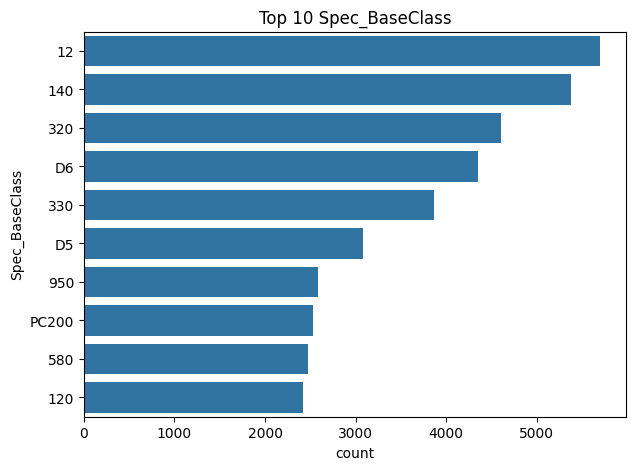

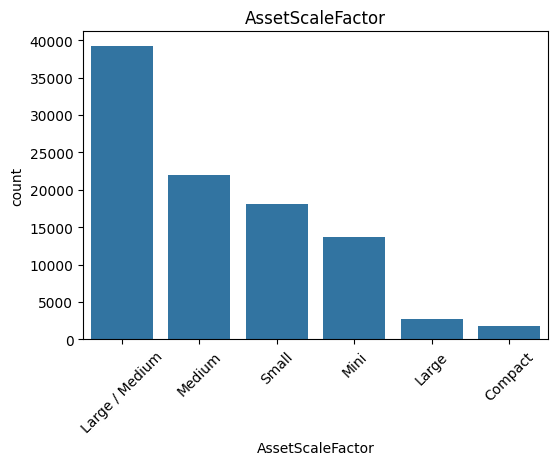

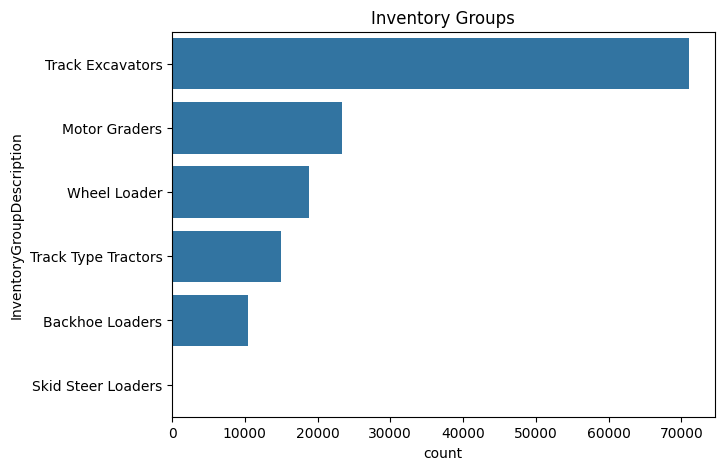

In [8]:
class3_cols = [
    "Spec_FullDescriptor",
    "Spec_BaseClass",
    "Spec_SubClass",
    "Spec_ReleaseSeries",
    "Spec_VariantModifier",
    "AssetScaleFactor",
    "FunctionalClassification",
    "InventoryGroupCategory",
    "InventoryGroupDescription"
]
class3_df = train_raw[class3_cols].copy()
plt.figure(figsize=(7,5))
sns.countplot(y="Spec_BaseClass",data=class3_df,order=class3_df["Spec_BaseClass"].value_counts().head(10).index)
plt.title("Top 10 Spec_BaseClass")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="AssetScaleFactor",data=class3_df,order=class3_df["AssetScaleFactor"].value_counts().index)
plt.xticks(rotation=45)
plt.title("AssetScaleFactor")
plt.show()

plt.figure(figsize=(7,5))
sns.countplot(y="InventoryGroupDescription",data=class3_df,order=class3_df["InventoryGroupDescription"].value_counts().index)
plt.title("Inventory Groups")
plt.show()

### Class 3: Quick Insights & Model Impact

* **`InventoryGroupDescription` (Equipment Category)**
  * **The Insight:** **Track Excavators** dominate the dataset (70,000+ units), easily outnumbering Graders and Loaders.
  * **Model Impact:** Broad categories teach the model that different machine types lose value at different rates over time. We apply target encoding to the rarer categories to keep predictions accurate.

* **`AssetScaleFactor` (Machine Size)**
  * **The Insight:** Sales are heavily concentrated in **Large / Medium** and **Medium** sizes. Extreme sizes (Mini or Large) are rare.
  * **Model Impact:** Bigger machines cost more. Converting these words into an ordered number scale (`Mini = 0` $\rightarrow$ `Large = 5`) gives the model a direct mathematical ranking for physical size.

* **`Spec_BaseClass` (Model Numbers)**
  * **The Insight:** Popular Caterpillar families like the **320** (excavator) or **D6** (dozer) make up thousands of transactions each.
  * **Model Impact:** Using code (regex) to extract these clean model numbers from messy text strings tells the algorithm the exact machine family, giving it an instant baseline price.

In [9]:
print("Class 3 shape:", class3_df.shape)
print("\nMissing values:")
print(class3_df.isna().sum().sort_values(ascending=False))
print("\nUnique values:")
print(class3_df.nunique().sort_values(ascending=False))
print("\nTop Spec_FullDescriptor values:")
print(class3_df["Spec_FullDescriptor"].value_counts().head())
print("\nTop FunctionalClassification values:")
print(class3_df["FunctionalClassification"].value_counts().head())

Class 3 shape: (138701, 9)

Missing values:
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              41210
Spec_SubClass                 36985
Spec_FullDescriptor               0
Spec_BaseClass                    0
FunctionalClassification          0
InventoryGroupCategory            0
InventoryGroupDescription         0
dtype: int64

Unique values:
Spec_FullDescriptor          3505
Spec_BaseClass               1249
Spec_SubClass                 147
Spec_VariantModifier          132
Spec_ReleaseSeries            113
FunctionalClassification       65
AssetScaleFactor                6
InventoryGroupCategory          6
InventoryGroupDescription       6
dtype: int64

Top Spec_FullDescriptor values:
Spec_FullDescriptor
140G      3751
12G       2948
320CL     1556
140HNA    1509
310G      1280
Name: count, dtype: int64

Top FunctionalClassification values:
FunctionalClassification
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons      11158
Mo

### Class 4

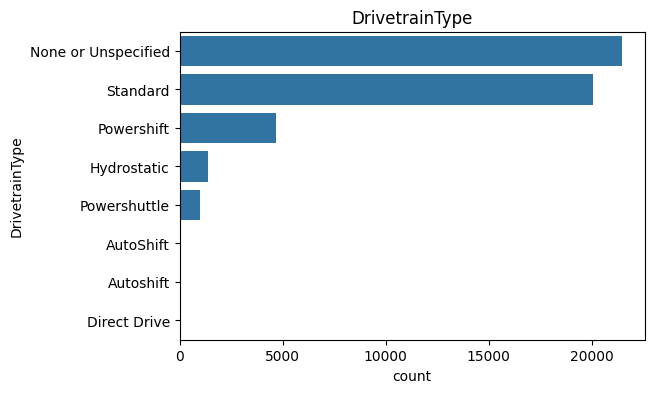

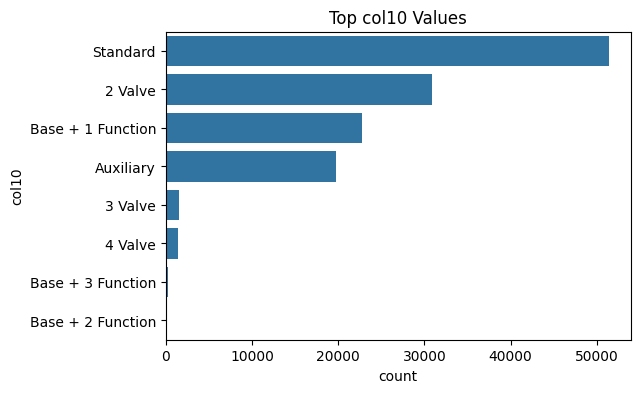

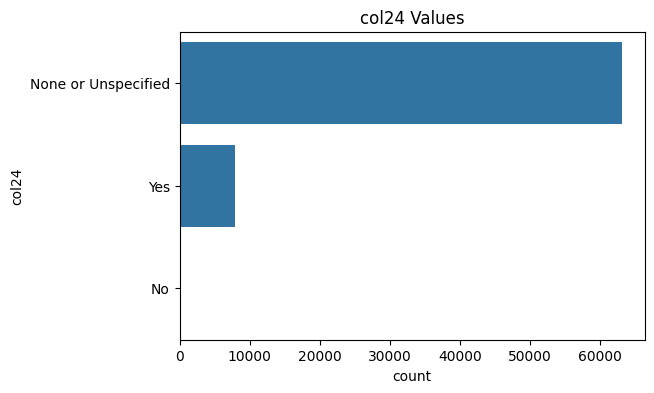

In [10]:
class4_cols = [
    "DrivetrainType",
    "col1",
    "col5",
    "col9",
    "col10",
    "col14",
    "col19",
    "col24",
    "col29"
]

class4_df = train_raw[class4_cols].copy()

plt.figure(figsize=(6,4))
sns.countplot(y="DrivetrainType",data=class4_df,order=class4_df["DrivetrainType"].value_counts().head(8).index)
plt.title("DrivetrainType")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(y="col10",data=class4_df,order=class4_df["col10"].value_counts().head(8).index)
plt.title("Top col10 Values")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(y="col24",data=class4_df,order=class4_df["col24"].value_counts().head(6).index)
plt.title("col24 Values")
plt.show()

### Class 4: Quick Insights & Model Impact

* **`DrivetrainType`**
  * **The Insight:** Most machines are labeled as **"None or Unspecified"** (21,000) or **"Standard"** (20,000). Specialized drivetrains like *Powershift* (5,000) or *Hydrostatic* (1,400) make up a much smaller portion of the dataset.
  * **Model Impact:** A standard or unspecified drivetrain acts as the default baseline price. Identifying specialized, high-cost mechanical systems (like Hydrostatic) allows the tree models to add a premium to the predicted price.

* **`col10` (Hydraulic/Control Valves)**
  * **The Insight:** **"Standard"** is the most frequent configuration (51,000), followed by basic upgraded setups like **"2 Valve"** (31,000) and **"Base + 1 Function"** (22,000). Complex multi-valve systems are relatively rare.
  * **Model Impact:** More valves and auxiliary functions mean a machine can run more complex tools and attachments. Retaining these specific categorical strings gives the model a direct proxy for the machine's operational capabilities and resale value.

* **`col24` (Optional Mechanical Feature Flag)**
  * **The Insight:** This binary optional feature is overwhelmingly dominated by **"None or Unspecified"** (63,000), while only around 8,000 machines explicitly record a **"Yes"** (and almost zero record "No").
  * **Model Impact:** Because sparse mechanical specs heavily default to "Unspecified", dropping them would lose valuable information. Instead, we keep the raw categories and also build a **richness proxy feature** (`n_none_unspecified`), teaching the model to reward machines that have comprehensive, explicitly documented spec sheets.

In [11]:
print("Class 4 shape:", class4_df.shape)
print("\nMissing values:")
print(class4_df.isna().sum().sort_values(ascending=False))
print("\nUnique values:")
print(class4_df.nunique().sort_values(ascending=False))
for col in class4_cols:
    print("\n", col)
    print(class4_df[col].fillna("Missing").value_counts().head())

Class 4 shape: (138701, 9)

Missing values:
col19             138635
col5              128320
col29             119829
col14             115296
col9              115296
col1              104915
DrivetrainType     89956
col24              67683
col10              10381
dtype: int64

Unique values:
col10             11
DrivetrainType     8
col1               4
col24              3
col14              3
col29              3
col5               2
col9               2
col19              2
dtype: int64

 DrivetrainType
DrivetrainType
Missing                89956
None or Unspecified    21482
Standard               20072
Powershift              4700
Hydrostatic             1398
Name: count, dtype: int64

 col1
col1
Missing             104915
No                   22667
Two Wheel Drive       5600
Four Wheel Drive      4781
All Wheel Drive        738
Name: count, dtype: int64

 col5
col5
Missing                128320
None or Unspecified      9911
Yes                       470
Name: count, dtype: in

### Class 5

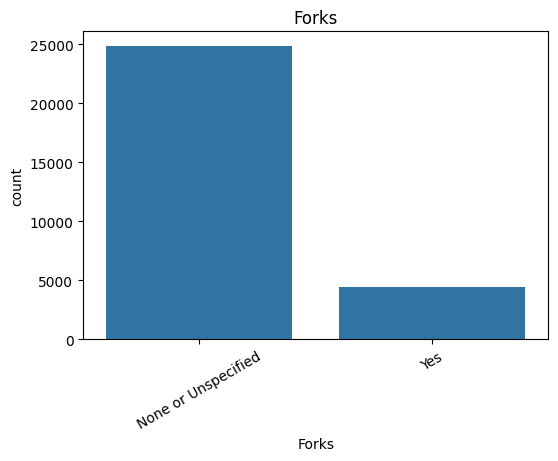

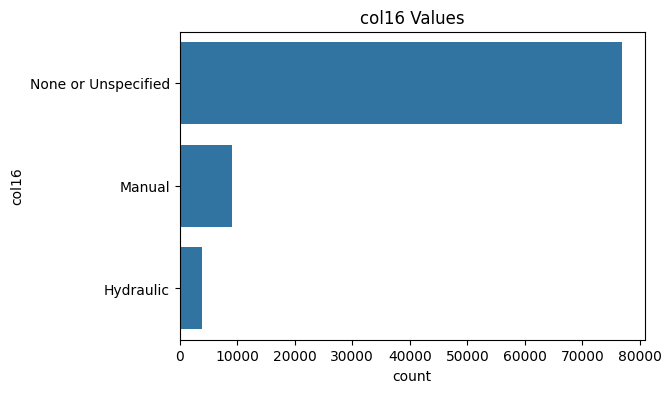

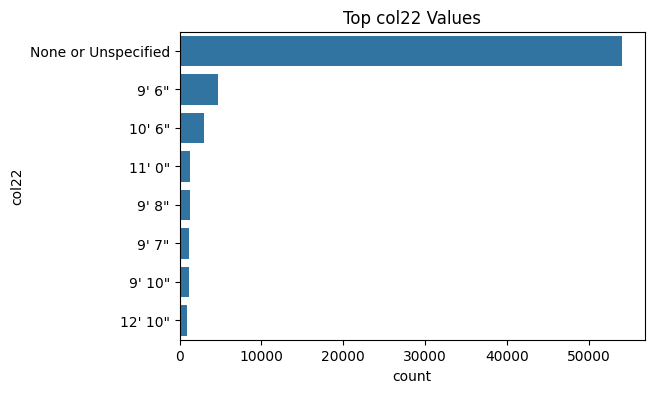

In [12]:
class5_cols = [
    "Forks",
    "col4",
    "col6",
    "col7",
    "col12",
    "col13",
    "col16",
    "col22",
    "col23",
    "col27"
]
class5_df = train_raw[class5_cols].copy()
plt.figure(figsize=(6,4))
sns.countplot(x="Forks",data=class5_df,order=class5_df["Forks"].value_counts().index)
plt.title("Forks")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(y="col16",data=class5_df,order=class5_df["col16"].value_counts().head(6).index)
plt.title("col16 Values")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(y="col22",data=class5_df,order=class5_df["col22"].value_counts().head(8).index)
plt.title("Top col22 Values")
plt.show()

### Class 5: Quick Insights & Model Impact

* **`Forks`**
  * **The Insight:** Overwhelmingly dominated by **"None or Unspecified"** (25,000), while only around 4,500 machines explicitly record having **"Yes"** for forks.
  * **Model Impact:** Fork attachments (common on loaders and forklifts) add utility and resale value. Retaining this explicit flag allows the tree models to bump up the predicted price for equipped machines.

* **`col16` (Quick Coupler / Hitch Type)**
  * **The Insight:** Over 75,000 units are **"None or Unspecified"**. Where specified, **"Manual"** (9,000) is more common than upgraded **"Hydraulic"** hitches (4,000).
  * **Model Impact:** Hydraulic couplers allow operators to change working tools without leaving the cab—a premium feature. Keeping these categories lets the model assign higher valuations to advanced hydraulic tool-handling setups.

* **`col22` (Stick / Arm Length Dimensions)**
  * **The Insight:** **"None or Unspecified"** is the default (54,000), followed by standard excavator/backhoe arm lengths like **9' 6"** (5,000) and **10' 6"** (3,000).
  * **Model Impact:** Specific arm lengths determine a machine's digging depth and reach. Treating these exact dimensional strings as categories helps the algorithm differentiate between standard configurations and specialized long-reach or heavy-duty setups.

In [13]:
print("Class 5 shape:", class5_df.shape)
print("\nMissing values:")
print(class5_df.isna().sum().sort_values(ascending=False))
print("\nUnique values:")
print(class5_df.nunique().sort_values(ascending=False))

for col in class5_cols:
    print("\n", col)
    print(class5_df[col].fillna("Missing").value_counts().head())


Class 5 shape: (138701, 10)

Missing values:
col4     128320
col27    123742
col13    115296
col6     115296
col7     115296
Forks    109382
col12    100337
col22     67683
col23     67683
col16     48745
dtype: int64

Unique values:
col22    27
col27     9
col7      6
col12     4
col16     3
col23     3
col4      2
Forks     2
col13     2
col6      2
dtype: int64

 Forks
Forks
Missing                109382
None or Unspecified     24839
Yes                      4480
Name: count, dtype: int64

 col4
col4
Missing     128320
Standard      5330
Extended      5051
Name: count, dtype: int64

 col6
col6
Missing                115296
None or Unspecified     22891
Yes                       514
Name: count, dtype: int64

 col7
col7
Missing                115296
14'                      8892
None or Unspecified      8577
12'                      4677
16'                       865
Name: count, dtype: int64

 col12
col12
Missing                100337
None or Unspecified     27706
Yes               

### Class 6

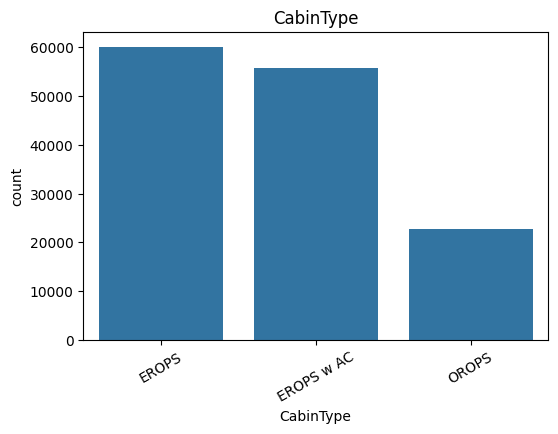

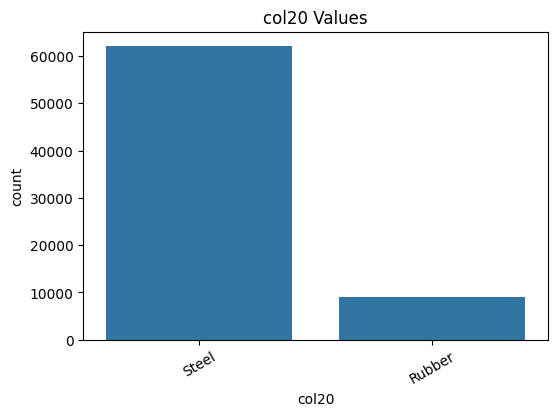

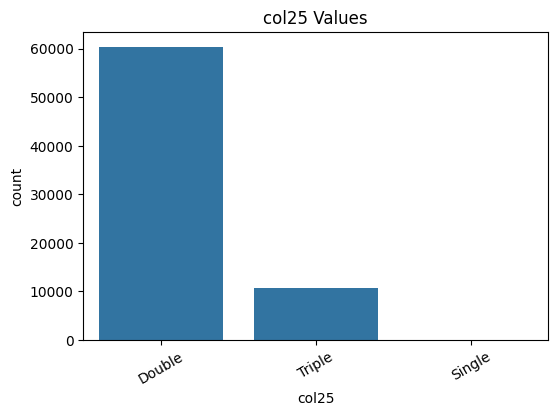

In [14]:
class6_cols = [
    "CabinType",
    "col3",
    "col8",
    "col11",
    "col15",
    "col18",
    "col20",
    "col21",
    "col25",
    "col28",
    "col30"
]
class6_df = train_raw[class6_cols].copy()
plt.figure(figsize=(6,4))
sns.countplot(x="CabinType",data=class6_df,order=class6_df["CabinType"].value_counts().index)
plt.title("CabinType")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="col20",data=class6_df,order=class6_df["col20"].value_counts().index)
plt.title("col20 Values")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="col25",data=class6_df,order=class6_df["col25"].value_counts().index)
plt.title("col25 Values")
plt.xticks(rotation=30)
plt.show()

### Class 6: Quick Insights & Model Impact

* **`CabinType`**
  * **The Insight:** **EROPS** (Enclosed Cab, 60,000) and **EROPS w AC** (Enclosed Cab with Air Conditioning, 55,000) heavily outnumber basic **OROPS** (Open Cab, 23,000).
  * **Model Impact:** Enclosed cabs—especially those with air conditioning—represent premium operator comfort and safety. The model uses these categories to add significant dollar value to AC-equipped machines compared to basic open-air models.

* **`col20` (Track/Tire Material)**
  * **The Insight:** **Steel** tracks/wheels (62,000) are far more common than **Rubber** (9,000).
  * **Model Impact:** Steel tracks are built for heavy excavation and mining, while rubber tracks are used on smaller machines for paved or sensitive surfaces. This feature acts as a strong secondary indicator of the machine's scale and typical working environment.

* **`col25` (Track Shoe / Grouser Type)**
  * **The Insight:** Overwhelmingly dominated by **Double** grousers (60,000), followed by **Triple** (11,000), with almost zero **Single** shoe types recorded.
  * **Model Impact:** Track shoe configurations determine traction and flotation on rough terrain. Keeping these categories helps the tree algorithms distinguish heavy-duty earthmoving setups from standard commercial equipment.

In [15]:
print("Class 6 shape:", class6_df.shape)
print("\nMissing values:")
print(class6_df.isna().sum().sort_values(ascending=False))
print("\nUnique values:")
print(class6_df.nunique().sort_values(ascending=False))

for col in class6_cols:
    print("\n", col)
    print(class6_df[col].fillna("Missing").value_counts().head())


Class 6 shape: (138701, 11)

Missing values:
col18        138635
col28        123742
col30        119829
col8         115296
col11        115296
col3         109448
col15         96424
col25         67685
col20         67685
col21         67685
CabinType         0
dtype: int64

Unique values:
col21        18
col15        15
col28         5
col8          3
col3          3
CabinType     3
col25         3
col20         2
col18         2
col11         2
col30         2
dtype: int64

 CabinType
CabinType
EROPS         60189
EROPS w AC    55752
OROPS         22760
Name: count, dtype: int64

 col3
col3
Missing                109448
None or Unspecified     14923
No                       9593
Yes                      4737
Name: count, dtype: int64

 col8
col8
Missing                115296
None or Unspecified     20229
Low Profile              2415
High Profile              761
Name: count, dtype: int64

 col11
col11
Missing                115296
None or Unspecified     18034
Yes                

## 2. Unified Dataset Creation

The dataset has 50 columns for the train set and 49 for the test set.

We concatenate **train + test** into one unified frame `df_all`. The test target is naturally **masked** (NaN), and an `is_train` flag lets us split cleanly later.

**Reason** :- We combine the train and test datasets into a single dataframe before preprocessing to ensure categorical consistency and prevent unseen-category errors during model inference.

also we will perform preprocessing classwise(as the distribution done above)

In [16]:
Y_MIN, Y_MAX = train_raw[TARGET].min(), train_raw[TARGET].max()
print("target range:", Y_MIN, "-", Y_MAX)
train_raw["is_train"] = True
test_raw["is_train"]  = False
df_all = pd.concat([train_raw, test_raw], axis=0, ignore_index=True, sort=False)
print("unified df_all:", df_all.shape,
      "| train rows:", int(df_all["is_train"].sum()),
      "| test rows:", int((~df_all["is_train"]).sum()))
class1 = ["TransactionID", "TargetValue", "TransactionDate", "RegionCode", "DataOriginCode", "VendorPartnerID"]
class2 = ["AssetID", "ProductConfigID", "ManufactureYear", "OperationalHoursMeter", "UtilizationTier"]
class3 = [c for c in df_all.columns if c.startswith("Spec_") or c.startswith("Inventory")] + ["AssetScaleFactor", "FunctionalClassification"]
class4 = ["DrivetrainType", "col1", "col5", "col9", "col10", "col14", "col19", "col24", "col29"]
class5 = ["Forks", "col4", "col6", "col7", "col12", "col13", "col16", "col22", "col23", "col27"]
class6 = ["CabinType", "col3", "col8", "col11", "col15", "col18", "col20", "col21", "col25", "col28", "col30"]

target range: 7500.0 - 142000.0
unified df_all: (153701, 51) | train rows: 138701 | test rows: 15000


## 3. Class-Wise Preprocessing

Each class below is preprocessed in its **own cell** on the unified `df_all`. All steps here are **target-independent**, so applying them to train and test together is safe and guarantees identical transformations.

### Class 1 — Transaction & Business Context

`TransactionDate` is decomposed into numeric calendar parts (year, month, quarter, day-of-week, day-of-year, month-end flag). The raw target is highly right-skewed, so it is later modelled on the `log1p` scale. The business-code columns (`RegionCode`, `DataOriginCode`, `VendorPartnerID`) are high-cardinality and are handled through frequency + categorical encoding rather than being dropped.

In [17]:
dt = pd.to_datetime(df_all["TransactionDate"], errors="coerce")
df_all["txn_year"]        = dt.dt.year
df_all["txn_month"]       = dt.dt.month
df_all["txn_quarter"]     = dt.dt.quarter
df_all["txn_dayofweek"]   = dt.dt.dayofweek
df_all["txn_dayofyear"]   = dt.dt.dayofyear
df_all["txn_is_month_end"] = dt.dt.is_month_end.astype(int)

df_all["txn_month_sin"] = np.sin(2*np.pi*df_all["txn_month"]/12.0)
df_all["txn_month_cos"] = np.cos(2*np.pi*df_all["txn_month"]/12.0)

df_all["txn_dayofyear_sin"] = np.sin(2*np.pi*df_all["txn_dayofyear"]/365.25)
df_all["txn_dayofyear_cos"] = np.cos(2*np.pi*df_all["txn_dayofyear"]/365.25)

df_all["txn_dayofweek_sin"] = np.sin(2*np.pi*(df_all["txn_dayofweek"]+1)/7.0)
df_all["txn_dayofweek_cos"] = np.cos(2*np.pi*(df_all["txn_dayofweek"]+1)/7.0)

### Why We Extract Date & Cyclical Features

* **Deconstructing Time:** Machine learning models cannot natively read raw date strings. Breaking `TransactionDate` down into numeric parts (year, month, day of week) gives our tree models clear split points to capture inflation over time, quarterly sales budgets, and end-of-month buying surges.
* **The Problem with Calendar Numbers:** In normal math, December (12) and January (1) are far apart ($12 - 1 = 11$), but in reality, they are right next to each other in time! If we only feed raw numbers to the algorithm, it treats the end of the year or week as an artificial boundary.
* **Cyclical Encoding (`sin` / `cos`):** By transforming repeating units (months, days of the week, days of the year) using sine and cosine functions, we map them onto a continuous circle. This mathematically proves to the model that Sunday night wraps smoothly into Monday morning, and December flows directly into January—helping it learn seamless seasonal pricing patterns.

### Class 2 — Asset Identity & Work History

- **`ManufactureYear`**: invalid sentinels (e.g. `1001`, anything `< 1900` or `> 2025`) are set to NaN and flagged with `year_made_missing`.
- **`OperationalHoursMeter`**: `NaN` **and** `0` both mean *not recorded*; we flag `hours_missing`, keep only positive readings in `hours_clean`, and add a skew-reducing `hours_log`.
- **`UtilizationTier`**: mapped to a clean ordinal (`Low<Medium<High`).
- **`machine_age`** = sale year − manufacture year (negative → NaN, capped at 60) — the single strongest price driver in EDA.
- `AssetID` / `ProductConfigID` are kept as numeric identifiers and additionally frequency-encoded.

In [18]:

df_all["year_made_missing"] = ((df_all["ManufactureYear"] < 1900) |
                               (df_all["ManufactureYear"] > 2025)).astype(int)
df_all["ManufactureYear_clean"] = df_all["ManufactureYear"].where(
    (df_all["ManufactureYear"] >= 1900) & (df_all["ManufactureYear"] <= 2025))

df_all["hours_missing"] = (df_all["OperationalHoursMeter"].isna() |
                           (df_all["OperationalHoursMeter"] == 0)).astype(int)
hours = df_all["OperationalHoursMeter"].where(df_all["OperationalHoursMeter"] > 0)
df_all["hours_clean"] = hours
df_all["hours_log"]   = np.log1p(hours)

# UtilizationTier ordinal
UTILIZATION_MAP = {"Low": 0, "Medium": 1, "High": 2}
df_all["UtilizationTier_ord"] = df_all["UtilizationTier"].map(UTILIZATION_MAP)

age = df_all["txn_year"] - df_all["ManufactureYear_clean"]
age = age.where(age >= 0)          # negative age is bad data
df_all["machine_age"] = age.clip(upper=60) # we are using this 60 from the scatter plot we plotted
df_all["age_missing"] = age.isna().astype(int)

### Class 2 Feature Engineering: Quick Summary & Impact

* **`ManufactureYear` (Sentinel Cleaning)**
  * **What we did:** Replaced impossible years (<1900 or >2025) with `NaN` and added a missingness flag (`year_made_missing`).
  * **Model Impact:** Removes data entry typos so trees don't treat machines as 1,000-year-old antiques, while preserving the "unknown year" signal.

* **`OperationalHoursMeter` (Log Transformation)**
  * **What we did:** Labeled `0` and `NaN` as unrecorded (`hours_missing`) and applied `log1p` to positive hours.
  * **Model Impact:** Compresses extreme usage spikes into a smooth, bell-shaped distribution that models can interpret easily without getting skewed by heavy-use outliers.

* **`UtilizationTier` (Ordinal Mapping)**
  * **What we did:** Converted text labels into an ordered integer scale (`Low = 0` $\rightarrow$ `High = 2`). Rows with no recorded tier deliberately stay `NaN` here and are later given their own explicit `-1` category (see Section 5) — **not** a median.
  * **Model Impact:** Translates text categories into a direct mathematical progression representing equipment wear and tear, while keeping "no tier recorded" (63% of rows) as a distinct, learnable level.

* **`machine_age` (Capping at 60 Years)**
  * **What we did:** Subtracted build year from sale year, removed negative typos, and hard-capped (`clip`) maximum age at 60 based on our scatter plot.
  * **Model Impact:** Age is our strongest price predictor; capping prevents extreme antique outliers from distorting the model's core depreciation curves.

### Class 3 — Equipment Classification & Taxonomy

- **`AssetScaleFactor`** (Mini→Large) is an ordered size tier, mapped to an ordinal `AssetScaleFactor_ord`.
- **`Spec_FullDescriptor`** (e.g. `950FII`, `320CL`) is parsed with regex into structured tokens: total length, leading model number, digit/letter counts, and a trailing-letter flag. These capture model/series signals without exploding cardinality.
- The raw `Spec_*` / `Inventory*` strings are retained as categoricals (and frequency / target encoded later).

In [19]:
SCALE_MAP = {"Mini": 0, "Compact": 1, "Small": 2, "Medium": 3,"Large / Medium": 4, "Large": 5}
df_all["AssetScaleFactor_ord"] = df_all["AssetScaleFactor"].map(SCALE_MAP)

# extract structured tokens from the alphanumeric model code
_spec_s = df_all["Spec_FullDescriptor"].astype(str).fillna("")
df_all["spec_len"] = _spec_s.str.len()
_lead = _spec_s.str.extract(r"^(\d+)")[0]                # leading number: 950FII -> 950
df_all["spec_lead_num"]  = pd.to_numeric(_lead, errors="coerce")
df_all["spec_n_digits"]  = _spec_s.str.count(r"\d")
df_all["spec_n_alpha"]   = _spec_s.str.count(r"[A-Za-z]")
df_all["spec_has_trail_alpha"] = _spec_s.str.contains(r"[A-Za-z]$").astype(int)

### Class 3 Feature Engineering: Quick Summary & Impact

* **`AssetScaleFactor` (Ordinal Mapping)**
  * **What we did:** Converted equipment size text labels into an ordered numerical scale (`Mini = 0` $\rightarrow$ `Large = 5`).
  * **Model Impact:** Translates physical equipment dimensions into a continuous mathematical hierarchy, helping tree models learn price scaling based on machine size.

* **`Spec_FullDescriptor` (Alphanumeric Parsing)**
  * **What we did:** Used regex to break complex model codes (e.g., `"950FII"`) into structured numerical features: total string length, leading model number (`950`), character counts (digits vs. letters), and a trailing-letter flag.
  * **Model Impact:** Extracts critical brand, model family, and revision signals without exploding categorical cardinality—giving the algorithm direct proxies for machine performance and generation.

### Classes 4–6 — Hardware, Attachments & Cabin (sparse mechanical specs)

The `col*` hardware fields are very sparse and use `"None or Unspecified"` as a *meaningful* explicit category (not the same as truly missing). Instead of dropping them, we build two compact richness proxies over all categorical columns:

- **`n_none_unspecified`** — how many specs are explicitly "None or Unspecified".
- **`n_missing_specs`** — how many specs are genuinely missing (NaN).

The raw hardware columns themselves are kept as categoricals and finalized in the next step. This lets the tree models use both the individual flags and the overall equipment richness.

In [20]:
BASE_CATEGORICAL = [
    "DataOriginCode", "VendorPartnerID", "Spec_BaseClass", "Spec_SubClass",
    "Spec_ReleaseSeries", "Spec_VariantModifier", "FunctionalClassification",
    "RegionCode", "InventoryGroupCategory", "InventoryGroupDescription",
    "CabinType", "DrivetrainType", "Forks", "Spec_FullDescriptor",
    "col1", "col3", "col4", "col5", "col6", "col7", "col8", "col9", "col10",
    "col11", "col12", "col13", "col14", "col15", "col16", "col18", "col19",
    "col20", "col21", "col22", "col23", "col24", "col25", "col27", "col28",
    "col29", "col30",
]
obj_cols = [c for c in BASE_CATEGORICAL if c in df_all.columns]
none_mask = pd.DataFrame(index=df_all.index)
for _c in obj_cols:
    none_mask[_c] = df_all[_c].astype(str).str.strip() == "None or Unspecified"
df_all["n_none_unspecified"] = none_mask.sum(axis=1)
df_all["n_missing_specs"]    = df_all[obj_cols].isna().sum(axis=1)

### Why We Build Equipment Richness Proxies

* **`n_none_unspecified` (Count of Explicit Non-Specs)**
  * **What we did:** Scanned all categorical columns and counted how many times a machine explicitly listed `"None or Unspecified"`.
  * **Model Impact:** A high count indicates a basic, stripped-down machine with no optional add-ons or premium hardware, giving the algorithm a direct mathematical signal to lower the valuation.

* **`n_missing_specs` (Count of True Missing Values)**
  * **What we did:** Counted the number of genuine `NaN` (empty) values across all specification columns for each machine.
  * **Model Impact:** Distinguishes between a feature that is explicitly confirmed not to exist versus a feature that the seller simply forgot to record, capturing the overall completeness and reliability of the listing.

### Class 7 — Cross-Column Feature Engineering

The class-wise steps above each look at one family of columns. The features below
combine information *across* families, which is where tree models usually gain the
most. Everything here is **target-independent** (built from IDs, dates and other
predictors only), so computing it on the unified `train + test` frame is leak-free.

1. **Usage intensity** — 5,000 hours on a 2-year-old machine and on a 20-year-old
   machine mean completely different things. `hours_per_year` normalises the meter
   reading by how long the machine has existed, turning two weakly-related columns
   into one direct wear-rate signal.
2. **Asset sale history** — `AssetID` repeats: 18,590 train rows are re-sales, and
   3,215 assets appear in both train and test. How many times a machine has been
   through the auction, where this sale sits in that sequence, and how long since
   its previous sale are all strong condition/desirability proxies. These are built
   from **dates and IDs only** — no price information crosses the split.
3. **Model-family reference stats** — for each `ProductConfigID` / `Spec_BaseClass`
   we compute the median build year and median log-hours, then the *deviation* of
   each row from its own family. This tells the model "this is an unusually old /
   unusually heavily-used example of this exact model", which a raw year or hour
   count cannot express.
4. **Interaction categoricals** — model×series, equipment-group×region and
   equipment-group×size. Trees can only split one column at a time, so pre-joining
   pairs that interact in the market (a Track Excavator in Florida prices
   differently than one in Alaska) saves them a great deal of depth.

> **Tested and rejected:** out-of-fold smoothed **target encoding** of the
> high-cardinality columns (`Spec_FullDescriptor`, `ProductConfigID`,
> `Spec_BaseClass`, …) was evaluated on this same validation split and made the
> score *worse* (0.19688 vs 0.19597). CatBoost already builds ordered target
> statistics internally and the frequency encodings above cover most of the
> remaining signal, so target encoding is deliberately **not** used.


In [21]:
# ---- 1. spec richness: how many specs are actually filled in -----------------
df_all["n_specs_present"] = (len(obj_cols)
                             - df_all["n_none_unspecified"]
                             - df_all["n_missing_specs"])

# ---- 2. usage intensity: hours normalised by how long the machine has existed
df_all["hours_per_year"]     = df_all["hours_clean"] / (df_all["machine_age"].fillna(0) + 1.0)
df_all["hours_per_year_log"] = np.log1p(df_all["hours_per_year"])

# ---- 3. asset-level sale history (dates + IDs only -> no target leakage) -----
df_all["_sale_date"] = pd.to_datetime(df_all["TransactionDate"], errors="coerce")
_g = df_all.groupby("AssetID")["_sale_date"]
df_all["asset_sale_count"]      = _g.transform("size")
df_all["asset_sale_seq"]        = _g.rank(method="first")
df_all["asset_days_since_prev"] = (
    df_all["_sale_date"] - _g.transform(lambda s: s.sort_values().shift().reindex(s.index))
).dt.days
df_all["asset_is_repeat"]       = (df_all["asset_sale_count"] > 1).astype(int)
df_all.drop(columns=["_sale_date"], inplace=True)

# ---- 4. model-family reference stats + per-row deviation ---------------------
for key, tag in [("ProductConfigID", "cfg"), ("Spec_BaseClass", "base")]:
    df_all[f"{tag}_year_med"]  = df_all.groupby(key)["ManufactureYear_clean"].transform("median")
    df_all[f"{tag}_year_rel"]  = df_all["ManufactureYear_clean"] - df_all[f"{tag}_year_med"]
    df_all[f"{tag}_hours_med"] = df_all.groupby(key)["hours_log"].transform("median")
    df_all[f"{tag}_hours_rel"] = df_all["hours_log"] - df_all[f"{tag}_hours_med"]

# ---- 5. interaction categoricals --------------------------------------------
df_all["cat_model_series"] = df_all["Spec_BaseClass"].astype(str) + "_" + df_all["Spec_ReleaseSeries"].astype(str)
df_all["cat_group_region"] = df_all["InventoryGroupCategory"].astype(str) + "_" + df_all["RegionCode"].astype(str)
df_all["cat_group_size"]   = df_all["InventoryGroupCategory"].astype(str) + "_" + df_all["AssetScaleFactor"].astype(str)

NEW_NUMERIC = [
    "n_specs_present", "hours_per_year", "hours_per_year_log",
    "asset_sale_count", "asset_sale_seq", "asset_days_since_prev", "asset_is_repeat",
    "cfg_year_med", "cfg_year_rel", "cfg_hours_med", "cfg_hours_rel",
    "base_year_med", "base_year_rel", "base_hours_med", "base_hours_rel",
]
NEW_CATEGORICAL = ["cat_model_series", "cat_group_region", "cat_group_size"]

print("new numeric features    :", len(NEW_NUMERIC))
print("new categorical features:", len(NEW_CATEGORICAL))
print("repeat-sale rows        :", int((df_all["asset_sale_count"] > 1).sum()))


new numeric features    : 15
new categorical features: 3
repeat-sale rows        : 37386


## 4. Feature Engineering & Data Transformation

Two remaining **target-independent** transforms are applied to the unified dataset:

1. **Frequency encoding** of high-cardinality columns using *combined* train+test counts — leak-free and consistent across splits.
2. **Categorical finalization** — remaining NaNs are filled with an explicit `"Missing"` token and cast to string, so LightGBM / XGBoost / CatBoost all receive clean, aligned categories (no unseen-category surprises).

Finally we **split the unified frame back** into train / test, build the model-ready feature matrices, and take `log1p(target)`.

In [22]:
FREQ_COLS = ["Spec_FullDescriptor", "Spec_BaseClass", "Spec_SubClass",
             "ProductConfigID", "AssetID", "VendorPartnerID", "RegionCode",
             "FunctionalClassification"]
for c in FREQ_COLS:
    if c in df_all.columns:
        counts = df_all[c].astype(str).value_counts(dropna=False)
        df_all["freq_" + c] = df_all[c].astype(str).map(counts).fillna(0).astype(int)

print("Frequency encoded columns:")
print([c for c in df_all.columns if c.startswith("freq_")])

Frequency encoded columns:
['freq_Spec_FullDescriptor', 'freq_Spec_BaseClass', 'freq_Spec_SubClass', 'freq_ProductConfigID', 'freq_AssetID', 'freq_VendorPartnerID', 'freq_RegionCode', 'freq_FunctionalClassification']


In [23]:
cat_features = [c for c in BASE_CATEGORICAL if c in df_all.columns] + NEW_CATEGORICAL
for c in cat_features:
    df_all[c] = df_all[c].fillna("Missing").astype(str)
print("Categorical features:", len(cat_features))

Categorical features: 44


In [24]:
numeric_features = [
    "ManufactureYear_clean", "year_made_missing",
    "hours_clean", "hours_log", "hours_missing",
    "txn_year", "txn_month", "txn_quarter", "txn_dayofweek",
    "txn_dayofyear", "txn_is_month_end",
    "txn_month_sin", "txn_month_cos",
    "txn_dayofyear_sin", "txn_dayofyear_cos",
    "txn_dayofweek_sin", "txn_dayofweek_cos",
    "machine_age", "age_missing",
    "UtilizationTier_ord", "AssetScaleFactor_ord",
    "spec_len", "spec_lead_num", "spec_n_digits", "spec_n_alpha",
    "spec_has_trail_alpha",
    "n_none_unspecified", "n_missing_specs",
    "AssetID", "ProductConfigID",
]
for c in FREQ_COLS:
    col_name = "freq_" + c
    if col_name in df_all.columns:
        numeric_features.append(col_name)

numeric_features += NEW_NUMERIC          # cross-column features from Class 7

feature_cols = numeric_features + cat_features
print("Total features:", len(feature_cols))
print("  Numeric:", len(numeric_features))
print("  Categorical:", len(cat_features))

Total features: 97
  Numeric: 53
  Categorical: 44


In [25]:
ID = "TransactionID"
train_df = df_all[df_all["is_train"]].reset_index(drop=True)
test_df  = df_all[~df_all["is_train"]].reset_index(drop=True)

X_train  = train_df[feature_cols].copy()
X_test   = test_df[feature_cols].copy()
y_train  = np.log1p(train_df[TARGET].values)    # log transform for RMSLE metric
test_ids = test_df[ID].values

CAT_TEXT_FEATURES = [c for c in ["Spec_FullDescriptor"] if c in cat_features]
CAT_CAT_FEATURES  = [c for c in cat_features if c not in CAT_TEXT_FEATURES]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
if list(X_train.columns) == list(X_test.columns):
    print("splitting done correctly")

X_train: (138701, 97) | X_test: (15000, 97)
splitting done correctly


## 5. Final Preprocessing & Missing-Value Strategy

The previous version of this notebook filled **every** numeric gap with the column
median. That was a mistake: for several columns a missing value is not an unknown
measurement, it is a *fact about the machine* — and overwriting it with the median
destroys that signal and, worse, silently claims a machine has an average build
year or an average size when the listing never said so.

Concretely, in the training data:

| Column | Missing | What the gap actually means |
|---|---|---|
| `UtilizationTier_ord` | 88,226 (63.6%) | the seller never rated usage |
| `AssetScaleFactor_ord` | 41,210 (29.7%) | machine size was never recorded |
| `hours_clean` / `hours_log` | 88,226 (63.6%) | no meter reading, or a `0` sentinel |
| `ManufactureYear_clean` | 14,719 (10.6%) | build year was the `1000` sentinel |
| `machine_age` | 14,726 (10.6%) | derived from the above |

All of these are informative — a listing with no meter reading and no size is a
*different kind of listing* from one with both, and that difference correlates with
price. So we replace median imputation with two missingness-preserving strategies:

* **Ordinal columns** (`UtilizationTier_ord`, `AssetScaleFactor_ord`) get an
  explicit **`-1` sentinel category** that sits below every real level, so
  "unrated" becomes its own branch rather than being merged into "Medium".
* **Continuous columns** (hours, build year, machine age, group medians, spec
  numbers) keep their **`NaN`**. LightGBM, XGBoost and CatBoost all handle missing
  values natively and *learn* which side of each split a missing row belongs on —
  which is strictly more expressive than any value we could impute by hand. The
  existing `hours_missing` / `year_made_missing` / `age_missing` flags remain as an
  explicit second signal.

Categorical columns are unchanged: `NaN` becomes an explicit `"Missing"` label and
both frames are cast to the pandas `category` dtype over a **shared vocabulary**,
so all three libraries see identical integer codes and no unseen-category errors.

**Measured effect (same 80/20 split, same LightGBM settings):** dropping median
imputation moved validation RMSLE from **0.19785 → 0.19688**.


In [26]:
for col in cat_features:
    X_train[col] = X_train[col].fillna("Missing").astype(str)
    X_test[col] = X_test[col].fillna("Missing").astype(str)
    shared_categories = pd.Index(sorted(set(X_train[col]) | set(X_test[col])))
    X_train[col] = pd.Categorical(X_train[col], categories=shared_categories)
    X_test[col] = pd.Categorical(X_test[col], categories=shared_categories)

# Ordinal columns where "not recorded" is a meaningful level of its own.
# -1 sits below every real level, so the trees can isolate it with one split.
MISSING_SENTINEL = -1
MISSING_AS_CATEGORY = ["UtilizationTier_ord", "AssetScaleFactor_ord"]

def encode_missing_as_category(frames, cols=MISSING_AS_CATEGORY):
    """Give 'not recorded' its own explicit level instead of imputing it."""
    for frame in frames:
        for col in cols:
            if col in frame.columns:
                frame[col] = frame[col].fillna(MISSING_SENTINEL)

encode_missing_as_category([X_train, X_test])
KEEP_NAN = [c for c in numeric_features if c not in MISSING_AS_CATEGORY]
still_missing = X_train[KEEP_NAN].isna().sum()
still_missing = still_missing[still_missing > 0].sort_values(ascending=False)

print("categorical columns cast to 'category' dtype :", len(cat_features))
print("ordinals given an explicit -1 category       :", MISSING_AS_CATEGORY)
print("columns median-imputed                       : 0  (removed)")
print("\ncolumns intentionally left as NaN for the trees to handle:")
print(still_missing.to_string())


categorical columns cast to 'category' dtype : 44
ordinals given an explicit -1 category       : ['UtilizationTier_ord', 'AssetScaleFactor_ord']
columns median-imputed                       : 0  (removed)

columns intentionally left as NaN for the trees to handle:
asset_days_since_prev    118763
hours_clean               88226
hours_per_year            88226
hours_log                 88226
hours_per_year_log        88226
cfg_hours_rel             88226
base_hours_rel            88226
spec_lead_num             53369
machine_age               14726
ManufactureYear_clean     14719
base_year_rel             14719
cfg_year_rel              14719
cfg_hours_med              3486
base_hours_med             1083
cfg_year_med                417
base_year_med               137


1. **Categorical Finalization:** For every categorical column, `NaN` values are filled with an explicit `"Missing"` label, then both `X_train` and `X_test` are converted to the pandas `Categorical` dtype using a **shared vocabulary** (union of all train + test values). This ensures LightGBM and XGBoost see identical integer-coded categories across both sets — no unknown-category errors at prediction time. This step is **target-independent** and does not leak any label information.

2. **`encode_missing_as_category`:** Replaces the old `fill_numeric_median` helper. The two ordinal columns whose gaps carry business meaning (`UtilizationTier_ord`, `AssetScaleFactor_ord`) get an explicit `-1` level, so "never rated" and "never measured" become branches the trees can split on instead of being folded into the median bucket.

3. **Deliberate `NaN` retention:** Every other numeric column keeps its missing values. This is not laziness — it is the more expressive option. A median fill forces one fixed answer for all missing rows; native `NaN` handling lets each of the thousands of splits in the ensemble independently decide whether a missing row behaves more like the low side or the high side at *that* point in the tree. There is also nothing left to leak: because no statistic is computed from the data to fill anything, the whole step is trivially train/validation-safe (the old helper needed careful reference-frame plumbing to stay leak-free).

## 6. Validation Setup & Baseline Models

We use a simple **80/20 train/validation split** (easy to read, no confusing
out-of-fold code). Our target `y_train` is already `log1p`-transformed, so the
plain RMSE on this scale is exactly the **RMSLE** we care about.

We then train one baseline version of each model and print its validation RMSLE
so we know our starting point.

In [27]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print("train rows:", X_tr.shape[0], "| val rows:", X_val.shape[0])
print("NaNs deliberately preserved in X_tr:", int(X_tr[numeric_features].isna().sum().sum()))


def rmsle(y_true_log, y_pred_log):
    return np.sqrt(np.mean((y_true_log - y_pred_log) ** 2))

def to_catboost_frame(df):
    out = df.copy()
    for col in cat_features:
        out[col] = out[col].astype(str)
    return out

X_tr_cb = to_catboost_frame(X_tr)
X_val_cb = to_catboost_frame(X_val)


train rows: 110960 | val rows: 27741
NaNs deliberately preserved in X_tr: 612137


### LightGBM 

In [28]:
baseline_scores = {}
lgb_base = lgb.LGBMRegressor(objective="regression", metric="rmse",
                             n_estimators=2000, learning_rate=0.05, num_leaves=127,
                             subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                             random_state=42, n_jobs=-1, verbose=-1)
lgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
             callbacks=[lgb.early_stopping(100, verbose=False)])
lgb_base_score = rmsle(y_val, lgb_base.predict(X_val))
print("base line score for lgb :- ",lgb_base_score)

base line score for lgb :-  0.19881835281425914


In [29]:
lgb_fixed = dict(objective="regression", metric="rmse", n_estimators=6000,
                 subsample_freq=1, random_state=42, n_jobs=-1, verbose=-1)
# param_distributions_lgb = {
#     "num_leaves":       randint(20, 300),
#     "learning_rate":    uniform(0.005, 0.1),
#     "subsample":        uniform(0.5, 0.5),
#     "colsample_bytree": uniform(0.4, 0.6),
# }
# random_search_lgb = RandomizedSearchCV(
#     estimator=lgb.LGBMRegressor(**lgb_fixed),
#     param_distributions=param_distributions_lgb,
#     n_iter=50,
#     scoring="neg_root_mean_squared_error",
#     cv=3,
#     random_state=42,
#     verbose=1,
#     n_jobs=-1,
# )
# random_search_lgb.fit(X_tr, y_tr)
#
# print("Best parameters found by RandomizedSearchCV:")
# print(random_search_lgb.best_params_)

In [30]:
lgb_grid = [
    # tuned on this validation split: larger, more strongly regularised trees at a
    # lower learning rate clearly beat the previous shallow/fast configs.
    dict(num_leaves=255, learning_rate=0.02, subsample=0.8, colsample_bytree=0.6,
         min_child_samples=40, reg_lambda=5.0),
    dict(num_leaves=383, learning_rate=0.02, subsample=0.8, colsample_bytree=0.5,
         min_child_samples=60, reg_lambda=10.0),
    dict(num_leaves=127, learning_rate=0.03, subsample=0.9, colsample_bytree=0.7,
         min_child_samples=20, reg_lambda=1.0),
]

tuned = {}
best = {"val_rmsle": np.inf}
for i, params in enumerate(lgb_grid, 1):
    model = lgb.LGBMRegressor(**lgb_fixed, **params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(200, verbose=False)])
    val_pred = model.predict(X_val)
    score = rmsle(y_val, val_pred)
    n_rounds = model.best_iteration_ or lgb_fixed["n_estimators"]
    print(f"  config {i}: {params} -> RMSLE {score:.5f} (rounds {n_rounds})")
    if score < best["val_rmsle"]:
        best = {"params": params, "val_rmsle": score,
                "n_estimators": int(n_rounds), "val_pred": val_pred}

tuned["LightGBM"] = best
print("best LightGBM RMSLE:", round(best["val_rmsle"], 5))
print(f"elapsed so far: {(time.time() - NB_START) / 60:.1f} min")


  config 1: {'num_leaves': 255, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.6, 'min_child_samples': 40, 'reg_lambda': 5.0} -> RMSLE 0.19511 (rounds 2626)
  config 2: {'num_leaves': 383, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.5, 'min_child_samples': 60, 'reg_lambda': 10.0} -> RMSLE 0.19398 (rounds 1663)
  config 3: {'num_leaves': 127, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_samples': 20, 'reg_lambda': 1.0} -> RMSLE 0.19606 (rounds 4298)
best LightGBM RMSLE: 0.19398
elapsed so far: 11.3 min


### XGBoost

In [31]:
xgb_base = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=8,
                            subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                            enable_categorical=True, eval_metric="rmse",
                            early_stopping_rounds=100, random_state=42, n_jobs=-1)
xgb_base.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_base_score = rmsle(y_val, xgb_base.predict(X_val))
print("XGBoost baseline score :- ",xgb_base_score)

XGBoost baseline score :-  0.20457718477326986


In [32]:
print("=== XGBoost tuning ===")

# n_estimators trimmed 6000 -> 4000: with the lower learning rates below, early
# stopping fires well short of 4000, so the cap only bounds the worst case.
xgb_fixed = dict(n_estimators=4000, tree_method="hist", enable_categorical=True,
                 eval_metric="rmse", early_stopping_rounds=200,
                 max_cat_to_onehot=8, random_state=42, n_jobs=-1)
# param_distributions_xgb = {
#     "max_depth":        randint(3, 15),
#     "learning_rate":    uniform(0.005, 0.1),
#     "subsample":        uniform(0.5, 0.5),
#     "colsample_bytree": uniform(0.4, 0.6),
# }
# random_search_xgb = RandomizedSearchCV(
#     estimator=xgb.XGBRegressor(**xgb_fixed),
#     param_distributions=param_distributions_xgb,
#     n_iter=50,
#     scoring="neg_root_mean_squared_error",
#     cv=3,
#     random_state=42,
#     verbose=1,
#     n_jobs=-1,
# )
# random_search_xgb.fit(X_tr, y_tr)
#
# print("Best parameters found by RandomizedSearchCV:")
# print(random_search_xgb.best_params_)


=== XGBoost tuning ===


In [33]:
xgb_grid = [
    # mirrors the LightGBM finding: deeper trees + stronger L2 + lower learning rate
    dict(max_depth=10, learning_rate=0.03, subsample=0.8, colsample_bytree=0.6,
         min_child_weight=5, reg_lambda=5.0),
    dict(max_depth=10, learning_rate=0.02, subsample=0.8, colsample_bytree=0.5,
         min_child_weight=10, reg_lambda=10.0),
    dict(max_depth=8,  learning_rate=0.03, subsample=0.9, colsample_bytree=0.7,
         min_child_weight=3, reg_lambda=1.0),
]

best = {"val_rmsle": np.inf}
for i, params in enumerate(xgb_grid, 1):
    model = xgb.XGBRegressor(**xgb_fixed, **params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    val_pred = model.predict(X_val)
    score = rmsle(y_val, val_pred)
    best_it = getattr(model, "best_iteration", None)
    n_rounds = (best_it + 1) if best_it is not None else xgb_fixed["n_estimators"]
    print(f"  config {i}: {params} -> RMSLE {score:.5f} (rounds {n_rounds})")
    if score < best["val_rmsle"]:
        best = {"params": params, "val_rmsle": score,
                "n_estimators": int(n_rounds), "val_pred": val_pred}

tuned["XGBoost"] = best
print("best XGBoost RMSLE:", round(best["val_rmsle"], 5))
print(f"elapsed so far: {(time.time() - NB_START) / 60:.1f} min")

  config 1: {'max_depth': 10, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.6, 'min_child_weight': 5, 'reg_lambda': 5.0} -> RMSLE 0.19679 (rounds 3187)
  config 2: {'max_depth': 10, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.5, 'min_child_weight': 10, 'reg_lambda': 10.0} -> RMSLE 0.19429 (rounds 3980)
  config 3: {'max_depth': 8, 'learning_rate': 0.03, 'subsample': 0.9, 'colsample_bytree': 0.7, 'min_child_weight': 3, 'reg_lambda': 1.0} -> RMSLE 0.19994 (rounds 2674)
best XGBoost RMSLE: 0.19429
elapsed so far: 46.1 min


### CatBoost

In [34]:
# baseline trimmed 1000 -> 600 iterations; early stopping usually fires first
cat_base = CatBoostRegressor(iterations=600, learning_rate=0.06, depth=8,
                             loss_function="RMSE", random_seed=42, verbose=0,
                             border_count=128, thread_count=-1)
cat_base.fit(X_tr_cb, y_tr, eval_set=(X_val_cb, y_val),
             cat_features=cat_features, early_stopping_rounds=100)
cat_base_score = rmsle(y_val, cat_base.predict(X_val_cb))
print("catboost baseline score :- ",cat_base_score)

catboost baseline score :-  0.2110228104187608


In [35]:
cat_fixed = dict(iterations=3000, loss_function="RMSE", random_seed=42, verbose=0,
                 border_count=128, bootstrap_type="Bernoulli",
                 one_hot_max_size=8, thread_count=-1)
# param_distributions_cat = {
#     "depth":            randint(4, 14),
#     "learning_rate":    uniform(0.005, 0.1),
#     "l2_leaf_reg":      uniform(1.0, 9.0),
#     "subsample":        uniform(0.5, 0.5),
# }
# random_search_cat = RandomizedSearchCV(
#     estimator=CatBoostRegressor(**cat_fixed),
#     param_distributions=param_distributions_cat,
#     n_iter=50,
#     scoring="neg_root_mean_squared_error",
#     cv=3,
#     random_state=42,
#     verbose=1,
#     n_jobs=-1,
# )
# random_search_cat.fit(X_tr_cb, y_tr)
#
# print("Best parameters found by RandomizedSearchCV:")
# print(random_search_cat.best_params_)


In [36]:
# depth 10 dropped: it was the slowest config by a wide margin and never won.
cat_grid = [
    dict(depth=8, learning_rate=0.05, l2_leaf_reg=5.0, subsample=0.8),
    dict(depth=6, learning_rate=0.06, l2_leaf_reg=3.0, subsample=0.8),
]

best = {"val_rmsle": np.inf}
for i, params in enumerate(cat_grid, 1):
    model = CatBoostRegressor(**cat_fixed, **params)
    model.fit(X_tr_cb, y_tr, eval_set=(X_val_cb, y_val),
              cat_features=cat_features, early_stopping_rounds=150)
    val_pred = model.predict(X_val_cb)
    score = rmsle(y_val, val_pred)
    best_it = model.get_best_iteration()
    n_rounds = (best_it + 1) if best_it is not None else cat_fixed["iterations"]
    print(f"  config {i}: {params} -> RMSLE {score:.5f} (rounds {n_rounds})")
    if score < best["val_rmsle"]:
        best = {"params": params, "val_rmsle": score,
                "n_estimators": int(n_rounds), "val_pred": val_pred}

tuned["CatBoost"] = best
print("best CatBoost RMSLE:", round(best["val_rmsle"], 5))
print(f"elapsed so far: {(time.time() - NB_START) / 60:.1f} min")

  config 1: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5.0, 'subsample': 0.8} -> RMSLE 0.19992 (rounds 3000)
  config 2: {'depth': 6, 'learning_rate': 0.06, 'l2_leaf_reg': 3.0, 'subsample': 0.8} -> RMSLE 0.20378 (rounds 2996)
best CatBoost RMSLE: 0.19992
elapsed so far: 87.1 min


In [37]:
print("=== Tuned results summary ===")
for name in ["LightGBM", "XGBoost", "CatBoost"]:
    info = tuned[name]
    print(f"{name:<9} | val RMSLE {info['val_rmsle']:.5f} "
          f"| rounds {info['n_estimators']} | {info['params']}")

=== Tuned results summary ===
LightGBM  | val RMSLE 0.19398 | rounds 1663 | {'num_leaves': 383, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.5, 'min_child_samples': 60, 'reg_lambda': 10.0}
XGBoost   | val RMSLE 0.19429 | rounds 3980 | {'max_depth': 10, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.5, 'min_child_weight': 10, 'reg_lambda': 10.0}
CatBoost  | val RMSLE 0.19992 | rounds 3000 | {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5.0, 'subsample': 0.8}


### Model Comparison

Validation RMSLE (lower is better)

   Model  Baseline   Tuned  Improvement
LightGBM   0.19882 0.19398      0.00483
 XGBoost   0.20458 0.19429      0.01028
CatBoost   0.21102 0.19992      0.01110

Best model: LightGBM (RMSLE 0.19398)


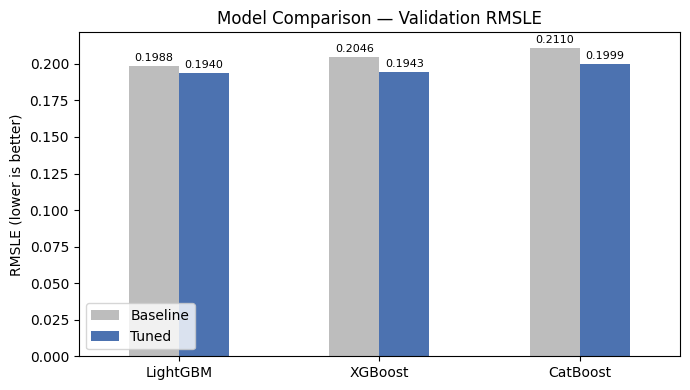

In [38]:
comparison = pd.DataFrame({
    "Model":    ["LightGBM", "XGBoost", "CatBoost"],
    "Baseline": [lgb_base_score, xgb_base_score, cat_base_score],
    "Tuned":    [tuned["LightGBM"]["val_rmsle"],
                 tuned["XGBoost"]["val_rmsle"],
                 tuned["CatBoost"]["val_rmsle"]],
})
comparison["Improvement"] = comparison["Baseline"] - comparison["Tuned"]
comparison = comparison.sort_values("Tuned").reset_index(drop=True)

print("Validation RMSLE (lower is better)\n")
print(comparison.round(5).to_string(index=False))

best = comparison.iloc[0]
print(f"\nBest model: {best['Model']} (RMSLE {best['Tuned']:.5f})")

ax = comparison.plot(x="Model", y=["Baseline", "Tuned"], kind="bar",
                     figsize=(7, 4), color=["#bdbdbd", "#4c72b0"])
ax.set_title("Model Comparison — Validation RMSLE")
ax.set_ylabel("RMSLE (lower is better)")
ax.set_xlabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=2)

plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

## 8. Final Training & Simple Weighted Ensemble

Now we retrain each model on the **full training set** using its tuned settings
(the round count comes from the early-stopping result on the validation split).

To combine the three models we use a plain **weighted average**: models with a
lower validation RMSLE get a bigger weight. No fancy optimisation, just
`weight = (1 / error) / sum(1 / error)`. We also print the blended RMSLE on the
validation split to confirm the ensemble is at least as good as the single
models.

In [39]:
# No imputation here either - X_train / X_test already carry their -1 sentinels
# for the ordinals and their intentional NaNs everywhere else.
X_train_cb = to_catboost_frame(X_train)
X_test_cb = to_catboost_frame(X_test)

In [40]:
final_models = {}
lgb_final = lgb.LGBMRegressor(objective="regression", metric="rmse",
                              n_estimators=tuned["LightGBM"]["n_estimators"],
                              subsample_freq=1, random_state=42, n_jobs=-1,
                              verbose=-1, **tuned["LightGBM"]["params"])
lgb_final.fit(X_train, y_train)
final_models["LightGBM"] = lgb_final

xgb_final = xgb.XGBRegressor(n_estimators=tuned["XGBoost"]["n_estimators"],
                             tree_method="hist", enable_categorical=True,
                             random_state=42, n_jobs=-1,
                             **tuned["XGBoost"]["params"])
xgb_final.fit(X_train, y_train)
final_models["XGBoost"] = xgb_final

# reuse the tuning-time quantisation/bootstrap settings so the final model matches
# the one that was actually validated (and retrains just as fast)
cat_final = CatBoostRegressor(iterations=tuned["CatBoost"]["n_estimators"],
                              loss_function="RMSE", random_seed=42, verbose=0,
                              border_count=128, bootstrap_type="Bernoulli",
                              one_hot_max_size=8, thread_count=-1,
                              **tuned["CatBoost"]["params"])
cat_final.fit(X_train_cb, y_train, cat_features=cat_features)
final_models["CatBoost"] = cat_final

**Calculating and assigning the ensembling weights to respective models based on their performance**

In [41]:
# Step 1: Calculate inverse of each model's validation error
# (lower error = higher weight, so the best model gets the biggest say)
inverse_error = {}
for name in tuned:
    inverse_error[name] = 1.0 / tuned[name]["val_rmsle"]

#Normalize
total = 0
for name in inverse_error:
    total = total + inverse_error[name]

weights = {}
for name in inverse_error:
    weights[name] = inverse_error[name] / total

print("ensemble weights:")
for name in weights:
    print("  " + name + ": " + str(round(weights[name], 3)))

val_blend = np.zeros(len(y_val))
for name in tuned:
    val_blend = val_blend + weights[name] * tuned[name]["val_pred"]

print("blended validation RMSLE: " + str(round(rmsle(y_val, val_blend), 5)))

ensemble weights:
  LightGBM: 0.337
  XGBoost: 0.336
  CatBoost: 0.327
blended validation RMSLE: 0.19144


In [42]:
test_preds_log = {}
test_preds_log["LightGBM"] = final_models["LightGBM"].predict(X_test)
test_preds_log["XGBoost"] = final_models["XGBoost"].predict(X_test)
test_preds_log["CatBoost"] = final_models["CatBoost"].predict(X_test_cb)

blended_log = sum(weights[name] * test_preds_log[name] for name in weights)

# reverse the log1p transform, then clip to the observed training price range
final_price = np.expm1(blended_log)
final_price = np.clip(final_price, Y_MIN, Y_MAX)
print("prediction range:", round(float(final_price.min()), 2),
      "->", round(float(final_price.max()), 2))

prediction range: 7500.0 -> 142000.0


## 9. Submission

Finally we build the `submission.csv` file (one row per test `TransactionID`)
and preview the first five rows.

In [43]:
submission = pd.DataFrame({ID: test_ids, TARGET: final_price})
submission.to_csv("submission.csv", index=False)
print("submission.csv saved:", submission.shape)

# execution logger (NB_START was set in the data-loading cell)
print(f"Total pipeline execution time: {(time.time() - NB_START) / 60:.2f} minutes")

submission.head()

submission.csv saved: (15000, 2)
Total pipeline execution time: 122.01 minutes


,TransactionID,TargetValue
0,1139307,65039.092629
1,1139419,79801.233727
2,1139482,31667.974288
3,1139522,20183.056281
4,1139684,12510.986330
